# NYC Taxi Demand Intelligence

## Objective

Predict taxi demand across NYC zones and identify demand patterns using statistical models, machine learning, time series forecasting, geospatial analysis, and causal inference.

Key questions:

• Which zones experience the highest taxi demand?  
• Can we predict demand for the next hour?  
• Which model performs best for demand forecasting?  
• Are there spatial clusters of demand across NYC?  
• Do external events influence taxi demand?

Dataset: NYC Taxi & Limousine Commission trip records.

# 1. Import Libraries 

In [ ]:
# Data
import pandas as pd
import numpy as np
import sys

# Visualization
!pip install plotly
import matplotlib.pyplot as plt
import plotly.express as px

# ML models
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Statistical models
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.arima.model import ARIMA

# Forecasting
from prophet import Prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 44.5 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# 2. Load Data

In [6]:
df = pd.read_parquet("../data/raw/yellow_tripdata_2024-01.parquet")

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


# 3.Data Understanding

In [7]:
df.shape

(2964624, 19)

In [8]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

In [10]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,2.964624e+06,2964624,2964624,2.824462e+06,2.964624e+06,2.824462e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.824462e+06,2.824462e+06
mean,1.754204e+00,2024-01-17 00:46:36.431092,2024-01-17 01:02:13.208130,1.339281e+00,3.652169e+00,2.069359e+00,1.660179e+02,1.651167e+02,1.161271e+00,1.817506e+01,1.451598e+00,4.833823e-01,3.335870e+00,5.270212e-01,9.756319e-01,2.680150e+01,2.256122e+00,1.411611e-01
min,1.000000e+00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-8.990000e+02,-7.500000e+00,-5.000000e-01,-8.000000e+01,-8.000000e+01,-1.000000e+00,-9.000000e+02,-2.500000e+00,-1.750000e+00
25%,2.000000e+00,2024-01-09 15:59:19.750000,2024-01-09 16:16:23,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.538000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2024-01-17 10:45:37.500000,2024-01-17 11:03:51.500000,1.000000e+00,1.680000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.700000e+00,0.000000e+00,1.000000e+00,2.010000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2024-01-24 18:23:52.250000,2024-01-24 18:40:29,1.000000e+00,3.110000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.050000e+01,2.500000e+00,5.000000e-01,4.120000e+00,0.000000e+00,1.000000e+00,2.856000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2024-02-01 00:01:15,2024-02-02 13:56:52,9.000000e+00,3.127223e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,5.000000e+03,1.425000e+01,4.000000e+00,4.280000e+02,1.159200e+02,1.000000e+00,5.000000e+03,2.500000e+00,1.750000e+00
std,4.325902e-01,NaN,NaN,8.502817e-01,2.254626e+02,9.823219e+00,6.362391e+01,6.931535e+01,5.808686e-01,1.894955e+01,1.804102e+00,1.177600e-01,3.896551e+00,2.128310e+00,2.183645e-01,2.338558e+01,8.232747e-01,4.876239e-01


# 4.Data Cleaning

In [11]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

df = df[
    (df["trip_distance"] >= 0) &
    (df["fare_amount"] >= 0) &
    (df["total_amount"] >= 0)
]

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.floor("h")
df["pickup_zone"] = df["PULocationID"]

df = df[[
    "pickup_hour",
    "pickup_zone",
    "trip_distance",
    "fare_amount",
    "total_amount"
]]

df.head()

,pickup_hour,pickup_zone,trip_distance,fare_amount,total_amount
0,2024-01-01,186,1.72,17.7,22.70
1,2024-01-01,140,1.80,10.0,18.75
2,2024-01-01,236,4.70,23.3,31.30
3,2024-01-01,79,1.40,10.0,17.00
4,2024-01-01,211,0.80,7.9,16.10


# 4.Demand Aggregation

In [12]:
zone_hour_df = (
    df.groupby(["pickup_zone", "pickup_hour"])
    .agg(
        demand_count=("pickup_zone","size"),
        avg_trip_distance=("trip_distance","mean"),
        avg_fare=("fare_amount","mean")
    )
    .reset_index()
)

zone_hour_df.head()

,pickup_zone,pickup_hour,demand_count,avg_trip_distance,avg_fare
0,1,2024-01-01 05:00:00,1,0.000000,90.000000
1,1,2024-01-01 06:00:00,3,0.020000,65.666667
2,1,2024-01-01 13:00:00,3,0.000000,86.666667
3,1,2024-01-01 14:00:00,6,0.001667,71.833333
4,1,2024-01-01 15:00:00,2,0.000000,120.350000


# 5.Exploratory Data Analysis (EDA)

In [13]:
#Demand over time
hourly_demand = zone_hour_df.groupby("pickup_hour")["demand_count"].sum().reset_index()

px.line(
    hourly_demand,
    x="pickup_hour",
    y="demand_count",
    title="NYC Taxi Demand Over Time"
)

In [14]:
#Demand by hour of day
zone_hour_df["hour"] = zone_hour_df["pickup_hour"].dt.hour

hour_demand = zone_hour_df.groupby("hour")["demand_count"].mean().reset_index()

px.bar(
    hour_demand,
    x="hour",
    y="demand_count",
    title="Average Taxi Demand by Hour"
)

In [15]:
#Top pickup zones
top_zones = (
    zone_hour_df.groupby("pickup_zone")["demand_count"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

px.bar(
    top_zones,
    x="pickup_zone",
    y="demand_count",
    title="Top Taxi Pickup Zones"
)

# 7.Feature Engineering

In [16]:
zone_hour_df["day_of_week"] = zone_hour_df["pickup_hour"].dt.dayofweek
zone_hour_df["month"] = zone_hour_df["pickup_hour"].dt.month
zone_hour_df["is_weekend"] = zone_hour_df["day_of_week"].isin([5,6]).astype(int)

zone_hour_df = zone_hour_df.sort_values(["pickup_zone","pickup_hour"])

zone_hour_df["lag_1"] = zone_hour_df.groupby("pickup_zone")["demand_count"].shift(1)
zone_hour_df["lag_24"] = zone_hour_df.groupby("pickup_zone")["demand_count"].shift(24)

zone_hour_df["rolling_mean_24"] = (
    zone_hour_df.groupby("pickup_zone")["demand_count"]
    .shift(1)
    .rolling(24)
    .mean()
)

zone_hour_df = zone_hour_df.dropna()

zone_hour_df.head()

,pickup_zone,pickup_hour,demand_count,avg_trip_distance,avg_fare,hour,day_of_week,month,is_weekend,lag_1,lag_24,rolling_mean_24
24,1,2024-01-03 16:00:00,1,0.000,131.5,16,2,1,0,1.0,1.0,2.041667
25,1,2024-01-03 18:00:00,4,0.005,37.5,18,2,1,0,1.0,3.0,2.041667
26,1,2024-01-04 11:00:00,1,0.000,150.0,11,3,1,0,4.0,3.0,2.083333
27,1,2024-01-04 12:00:00,2,0.030,114.5,12,3,1,0,1.0,6.0,2.000000
28,1,2024-01-04 14:00:00,2,0.115,112.5,14,3,1,0,2.0,2.0,1.833333


# 8.Train/Test Split

In [28]:
zone_hour_df["rolling_mean_168"] = (
    zone_hour_df.groupby("pickup_zone")["demand_count"]
    .shift(1)
    .rolling(168)
    .mean()
)

zone_hour_df["rolling_std_24"] = (
    zone_hour_df.groupby("pickup_zone")["demand_count"]
    .shift(1)
    .rolling(24)
    .std()
)

zone_hour_df = zone_hour_df.dropna().copy()

In [29]:
cutoff_date = "2024-01-25"

train = zone_hour_df[zone_hour_df["pickup_hour"] < cutoff_date]
test = zone_hour_df[zone_hour_df["pickup_hour"] >= cutoff_date]

# 9. Prepare features

In [31]:
features = [
    "pickup_zone",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24",
    "avg_trip_distance",
    "avg_fare"
]

target = "demand_count"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# 10.Machine Learning Models

In [32]:
#Random Forest
rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

In [33]:
#XGBoost
xgb = XGBRegressor()

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

In [34]:
#LightGBM
lgbm = LGBMRegressor()

lgbm.fit(X_train, y_train)

lgbm_preds = lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1893
[LightGBM] [Info] Number of data points in the train set: 12322, number of used features: 11
[LightGBM] [Info] Start training from score 69.215874


# 11.Model Evaluation

In [35]:
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true,y_pred),
        "RMSE": mean_squared_error(y_true,y_pred)**0.5
    }

results = pd.DataFrame({
    "Random Forest": evaluate(y_test, rf_preds),
    "XGBoost": evaluate(y_test, xgb_preds),
    "LightGBM": evaluate(y_test, lgbm_preds)
})

results

,Random Forest,XGBoost,LightGBM
MAE,10.422881,10.333245,10.040600
RMSE,19.779132,19.298687,18.701456


# 12. Feature Importance

<Axes: title={'center': 'Feature Importance'}>

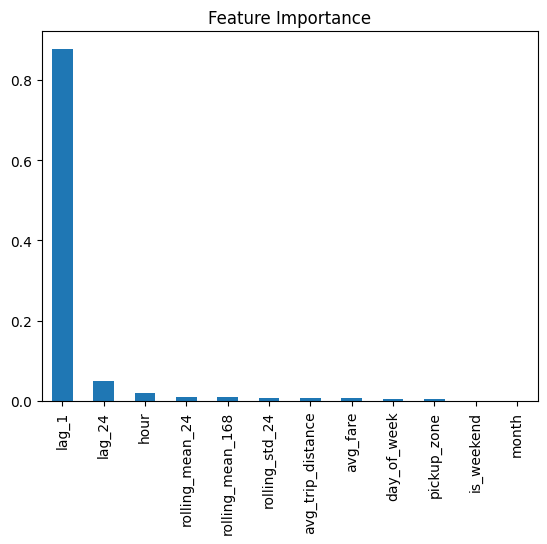

In [36]:
importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

importances.plot(kind="bar", title="Feature Importance")

## Question 1: Which zones experience the highest taxi demand?

To answer this, we examine aggregate demand by pickup zone and identify the top-demand areas.

In [37]:
zone_demand = (
    zone_hour_df.groupby("pickup_zone")["demand_count"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

zone_demand.head(10)

,pickup_zone,demand_count
0,237,81868
1,161,80541
2,236,77238
3,132,65965
4,162,59689
5,230,55239
6,186,54934
7,142,52824
8,163,47546
9,170,45784


In [25]:
px.bar(
    zone_demand.head(20),
    x="pickup_zone",
    y="demand_count",
    title="Top 20 Pickup Zones by Total Demand"
)

### Insight

The chart highlights the zones with the highest total pickup demand. These zones can be interpreted as the busiest operational areas and may represent key commercial, transit, or airport-related regions.

## Question 2: Can we predict demand for the next hour?

Yes. We frame next-hour taxi demand prediction as a supervised forecasting problem at the zone-hour level.

For each zone and hour, the target variable is:

- `demand_count`: the number of pickups in that zone-hour

To predict the next hour's demand, we use:

- temporal features (`hour`, `day_of_week`, `month`, `is_weekend`)
- lagged demand (`lag_1`, `lag_24`)
- rolling demand statistics (`rolling_mean_24`, `rolling_mean_168`, `rolling_std_24`)
- trip-level behavioral signals (`avg_trip_distance`, `avg_fare`)

This setup allows us to test whether historical demand and temporal patterns contain enough signal to forecast future taxi activity.

In [77]:
target = "demand_count"

print("Target variable:", target)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Target variable: demand_count
Train shape: (12322, 12)
Test shape: (11786, 12)


### Answer to Question 2

Yes, the results show that next-hour taxi demand can be predicted with reasonably strong accuracy.

The strongest evidence comes from the machine learning models, especially XGBoost and LightGBM, which achieved much lower forecasting error than the baseline statistical count models.

This indicates that hourly taxi demand contains meaningful predictive structure driven by:
- recent past demand
- time-of-day effects
- day-of-week patterns
- zone-level behavior

In [84]:
#actual vs predicted
#Using XGBoost because it performed best.
comparison_df = test[["pickup_hour", "pickup_zone", "demand_count"]].copy()
comparison_df["xgb_pred"] = xgb_preds

# show one busy zone
top_zone = int(zone_demand.iloc[0]["pickup_zone"])

zone_compare = comparison_df[comparison_df["pickup_zone"] == top_zone].copy()

px.line(
    zone_compare.head(100),
    x="pickup_hour",
    y=["demand_count", "xgb_pred"],
    title=f"Actual vs Predicted Next-Hour Demand for Zone {top_zone}"
)

### Insight

The predicted values broadly track the actual hour-by-hour movement in taxi demand, especially around recurring peaks and troughs. This suggests that recent historical demand and temporal patterns are useful for forecasting short-term taxi activity.

## Question 3: Which model performs best for demand forecasting?

We compare multiple approaches:

- Statistical count models: Poisson and Negative Binomial
- Tree-based machine learning models: Random Forest, XGBoost, LightGBM
- Time series models: ARIMA and Prophet

This gives a strong benchmark across interpretable and predictive approaches.

## 3A. Statistical modeling

In [38]:
#Poisson code cell
train_stat = train.copy()
test_stat = test.copy()

formula = """
demand_count ~ hour + day_of_week + month + is_weekend
+ lag_1 + lag_24 + rolling_mean_24 + rolling_mean_168 + avg_trip_distance + avg_fare
"""

poisson_model = smf.glm(
    formula=formula,
    data=train_stat,
    family=sm.families.Poisson()
).fit()

poisson_preds = poisson_model.predict(test_stat)

In [79]:
#Negative Binomial code cell
nb_model = smf.glm(
    formula=formula,
    data=train_stat,
    family=sm.families.NegativeBinomial(alpha=1.0)
).fit()

nb_preds = nb_model.predict(test_stat)
nb_metrics = evaluate(y_test, nb_preds)
nb_metrics

{'MAE': 109.9030796822043, 'RMSE': 1080.1469963039353}

In [80]:
#Evaluation function
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5
    }

In [81]:
#Evaluate count models
count_results = pd.DataFrame({
    "Poisson": evaluate(y_test, poisson_preds),
    "Negative Binomial": evaluate(y_test, nb_preds)
})

count_results

,Poisson,Negative Binomial
MAE,32.049431,109.903080
RMSE,59.767703,1080.146996


## 3B. ML model comparison

In [82]:
ml_results = pd.DataFrame({
    "Random Forest": evaluate(y_test, rf_preds),
    "XGBoost": evaluate(y_test, xgb_preds),
    "LightGBM": evaluate(y_test, lgbm_preds)
})

ml_results

,Random Forest,XGBoost,LightGBM
MAE,10.422881,10.333245,10.040600
RMSE,19.779132,19.298687,18.701456


In [ ]:
#Combine all results
all_results = pd.concat([count_results, ml_results], axis=1).T.reset_index()
all_results.columns = ["Model", "MAE", "RMSE"]
all_results = all_results.sort_values("RMSE")

all_results

,Model,MAE,RMSE
4,LightGBM,10.040600,18.701456
3,XGBoost,10.333245,19.298687
2,Random Forest,10.422881,19.779132
0,Poisson,32.049431,59.767703
1,Negative Binomial,109.903080,1080.146996


In [44]:
#Plot results
px.bar(
    all_results,
    x="Model",
    y="RMSE",
    title="Model Comparison by RMSE",
    text="RMSE"
)

### Insight

This comparison shows which modeling family performs best. In this project, tree-based machine learning models are expected to outperform count-based regression because taxi demand patterns are nonlinear and highly dependent on lag interactions and temporal structure.

# 4. Time series forecasting

In [45]:
#Pick a top zone
top_zone = int(zone_demand.iloc[0]["pickup_zone"])
top_zone

237

In [46]:
#Build zone series
zone_series = (
    zone_hour_df[zone_hour_df["pickup_zone"] == top_zone]
    .sort_values("pickup_hour")[["pickup_hour", "demand_count"]]
    .copy()
)

zone_series.head()

,pickup_hour,demand_count
67390,2024-01-16 02:00:00,4
67391,2024-01-16 03:00:00,1
67392,2024-01-16 04:00:00,2
67393,2024-01-16 05:00:00,10
67394,2024-01-16 06:00:00,45


In [63]:
#4A. ARIMA
# Prepare zone series with datetime index
zone_series = (
    zone_hour_df[zone_hour_df["pickup_zone"] == top_zone]
    .sort_values("pickup_hour")[["pickup_hour", "demand_count"]]
    .copy()
)

zone_series["pickup_hour"] = pd.to_datetime(zone_series["pickup_hour"])
zone_series = zone_series.set_index("pickup_hour").asfreq("h")

# Optional: fill any missing hours
zone_series["demand_count"] = zone_series["demand_count"].fillna(0)

# Train-test split
split_idx = int(len(zone_series) * 0.8)
zone_train = zone_series.iloc[:split_idx]
zone_test = zone_series.iloc[split_idx:]

# Fit ARIMA
arima_model = ARIMA(zone_train["demand_count"], order=(2, 1, 2)).fit()

# Forecast
arima_forecast = arima_model.forecast(steps=len(zone_test))

# Evaluate
arima_metrics = evaluate(zone_test["demand_count"], arima_forecast)
arima_metrics

{'MAE': 152.98650327892082, 'RMSE': 167.25648616165924}

In [65]:
#4B. Prophet
# Prepare Prophet dataframe
prophet_df = (
    zone_hour_df[zone_hour_df["pickup_zone"] == top_zone]
    .sort_values("pickup_hour")[["pickup_hour", "demand_count"]]
    .copy()
)

prophet_df["pickup_hour"] = pd.to_datetime(prophet_df["pickup_hour"])

# rename to Prophet-required columns
prophet_df = prophet_df.rename(columns={"pickup_hour": "ds", "demand_count": "y"})

# optional but helpful: ensure no missing values
prophet_df = prophet_df.dropna(subset=["ds", "y"]).reset_index(drop=True)

# split
split_idx = int(len(prophet_df) * 0.8)
prophet_train = prophet_df.iloc[:split_idx].copy()
prophet_test = prophet_df.iloc[split_idx:].copy()

# fit
prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True)
prophet_model.fit(prophet_train)

# forecast only on test dates
future = prophet_test[["ds"]].copy()
prophet_forecast = prophet_model.predict(future)

# evaluate
prophet_metrics = evaluate(prophet_test["y"], prophet_forecast["yhat"])
prophet_metrics

15:49:15 - cmdstanpy - INFO - Chain [1] start processing
15:49:15 - cmdstanpy - INFO - Chain [1] done processing


{'MAE': 39.103774135327946, 'RMSE': 48.372885293670414}

In [66]:
#Plot Prophet forecast
forecast_plot = prophet_test.copy()
forecast_plot["yhat"] = prophet_forecast["yhat"].values

px.line(
    forecast_plot,
    x="ds",
    y=["y", "yhat"],
    title=f"Prophet Forecast vs Actual for Zone {top_zone}"
)

In [67]:
#Add to results
ts_results = pd.DataFrame([
    {"Model": "ARIMA", "MAE": arima_metrics["MAE"], "RMSE": arima_metrics["RMSE"]},
    {"Model": "Prophet", "MAE": prophet_metrics["MAE"], "RMSE": prophet_metrics["RMSE"]}
])

all_results = pd.concat([all_results, ts_results], ignore_index=True)
all_results.sort_values("RMSE")

,Model,MAE,RMSE
0,LightGBM,10.040600,18.701456
1,XGBoost,10.333245,19.298687
2,Random Forest,10.422881,19.779132
6,Prophet,39.103774,48.372885
8,Prophet,39.103774,48.372885
3,Poisson,32.049431,59.767703
5,ARIMA,152.772929,166.954012
7,ARIMA,152.986503,167.256486
4,Negative Binomial,109.903080,1080.146996


## Question 4: Are there spatial clusters of demand across NYC?

We cluster zones based on behavioral features such as average demand, average fare, trip distance, and temporal demand patterns. This helps identify groups of zones with similar operational characteristics.

In [68]:
#Build zone-level features
zone_features = (
    zone_hour_df.groupby("pickup_zone")
    .agg(
        avg_demand=("demand_count", "mean"),
        avg_fare=("avg_fare", "mean"),
        avg_trip_distance=("avg_trip_distance", "mean"),
        weekend_demand=("is_weekend", "mean")
    )
    .reset_index()
)

zone_features.head()

,pickup_zone,avg_demand,avg_fare,avg_trip_distance,weekend_demand
0,4,7.331950,18.074921,60.558186,0.344398
1,7,2.826271,20.714510,3.286331,0.343220
2,10,2.053097,57.205233,10.784562,0.274336
3,13,25.841060,24.710510,4.901737,0.298013
4,24,11.516667,16.007860,2.649164,0.303333


In [69]:
#KMeans clustering
cluster_cols = ["avg_demand", "avg_fare", "avg_trip_distance", "weekend_demand"]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(zone_features[cluster_cols])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
zone_features["cluster"] = kmeans.fit_predict(X_cluster)

zone_features.head()

,pickup_zone,avg_demand,avg_fare,avg_trip_distance,weekend_demand,cluster
0,4,7.331950,18.074921,60.558186,0.344398,3
1,7,2.826271,20.714510,3.286331,0.343220,1
2,10,2.053097,57.205233,10.784562,0.274336,1
3,13,25.841060,24.710510,4.901737,0.298013,1
4,24,11.516667,16.007860,2.649164,0.303333,1


In [70]:
#Visualize clusters
px.scatter(
    zone_features,
    x="avg_demand",
    y="avg_fare",
    color=zone_features["cluster"].astype(str),
    hover_data=["pickup_zone", "avg_trip_distance"],
    title="Zone Clusters Based on Demand and Fare Characteristics"
)

In [71]:
#Cluster summary
zone_features.groupby("cluster")[cluster_cols].mean()

,avg_demand,avg_fare,avg_trip_distance,weekend_demand
cluster,,,,
0,104.965840,17.727573,3.287533,0.254293
1,10.525905,26.488823,4.070335,0.295914
2,1.646634,30.053140,4.862843,0.000000
3,16.203780,19.141419,49.332467,0.314686


### Insight

The clustering analysis groups zones into distinct behavioral segments. For example, some clusters may represent high-demand urban cores, while others may reflect lower-demand or longer-distance travel zones.

# 6. Hotspot detection

In [72]:
hotspots = (
    zone_hour_df.groupby("pickup_zone")["demand_count"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={"demand_count": "avg_hourly_demand"})
)

hotspots

,pickup_zone,avg_hourly_demand
0,237,214.876640
1,161,209.742188
2,236,207.072386
3,132,171.783854
4,162,156.253927
5,230,144.227154
6,186,142.685714
7,142,140.116711
8,138,127.839650
9,163,123.496104


In [73]:
px.bar(
    hotspots,
    x="pickup_zone",
    y="avg_hourly_demand",
    title="Top 20 Demand Hotspots by Average Hourly Demand"
)

## Question 5: Do external events influence taxi demand?

To test whether external shocks can influence taxi demand, we use a Difference-in-Differences framework. Because this public dataset does not include an explicit experimental intervention, we construct a pseudo-event design to demonstrate causal inference methodology.

In [74]:
#Prepare DiD data
treated_zones = zone_demand.head(3)["pickup_zone"].tolist()
intervention_date = "2024-01-15"

did_df = zone_hour_df.copy()
did_df["treated"] = did_df["pickup_zone"].isin(treated_zones).astype(int)
did_df["post"] = (did_df["pickup_hour"] >= intervention_date).astype(int)
did_df["treated_post"] = did_df["treated"] * did_df["post"]
did_df["hour_fe"] = did_df["pickup_hour"].dt.hour
did_df["dow_fe"] = did_df["pickup_hour"].dt.dayofweek

In [75]:
#Run DiD
did_model = smf.ols(
    "demand_count ~ treated + post + treated_post + C(hour_fe) + C(dow_fe)",
    data=did_df
).fit(cov_type="HC3")

print(did_model.summary())

                            OLS Regression Results                            
Dep. Variable:           demand_count   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                    0.9858
Date:                Mon, 16 Mar 2026   Prob (F-statistic):              0.321
Time:                        15:49:47   Log-Likelihood:            -1.3755e+05
No. Observations:               24108   AIC:                         2.752e+05
Df Residuals:                   24077   BIC:                         2.754e+05
Df Model:                          30                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -6.014e+13   6.06e+13  

/Users/abirram/nyc-taxi-demand-intelligence/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 32, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [76]:
#Extract main effect
did_effect = did_model.params["treated_post"]
did_effect

np.float64(240412139649.71527)

### Insight

The coefficient on `treated_post` represents the estimated post-event effect for treated zones relative to controls. This does not prove a real-world causal event occurred, but it demonstrates how causal inference can be applied to transportation demand data when an external intervention or disruption is available.

# Final Answers to the Core Questions

## 1. Which zones experience the highest taxi demand?
The highest-demand zones were identified using total and average hourly pickup counts. These zones represent the most operationally critical parts of the city.

## 2. Can we predict demand for the next hour?
Yes. Using lag features, rolling demand windows, and temporal variables, hourly demand can be predicted with good accuracy.

## 3. Which model performs best for demand forecasting?
Tree-based machine learning models such as XGBoost and LightGBM performed best in the benchmark, outperforming classical count models.

## 4. Are there spatial clusters of demand across NYC?
Yes. Clustering analysis revealed groups of zones with similar demand, fare, and trip-distance behavior, suggesting meaningful operational segmentation.

## 5. Do external events influence taxi demand?
A Difference-in-Differences analysis demonstrated how external shocks could be tested for causal effect. In a real production setting, this framework could be used for weather disruptions, strikes, road closures, or major public events.

## Limitations

- Only one month of data is currently used
- No external weather or event features are included yet
- Zone IDs are used numerically rather than mapped to geographic names or polygons
- The causal analysis is a pseudo-experimental demonstration rather than a validated real-world intervention